# Seaborn

---
## Introducción

Seaborn es otro paquete de visualización de datos de Python.

Al igual que Matplolib, Seaborn es una librería de dibujo de trazos 2D, lo que implica que dibujará gráficos de líneas.

A pesar de que aquí veremos los aspectos básicos de la misma, os dejo el enlace a su documentación oficial en [este enlace](https://seaborn.pydata.org/api.html). También os dejo una serie de Notebooks donde presentan varios [ejemplos de uso](https://www.kaggle.com/getting-started/125556).

Al igual que pasaba anteriormente con el resto de librerías, Seaborn no viene instalado por defecto en Visual Studio Code por lo que tendremos que hacerlo nosotros:

In [ ]:
# Recuerda que pip es el gestor de paquetes por defecto de Python
pip install seaborn

Hay que tener en cuenta que Seaborn es una extensión de Matplotlib.Pyplot por lo que necesitará importar este módulo para poder funcionar. Además, como Mayplotlib necesita de NumPy aquí también será necesario por extensión.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# Siglas utilizadas por defecto para Seaborn
import seaborn as sns

---
## Primeros pasos

Como primer ejemplo, veremos cómo mostrar rápidamente por pantalla una gráfica con los datos de un dataset muy conocido: [iris](https://es.wikipedia.org/wiki/Conjunto_de_datos_flor_iris)

In [ ]:
# línea utilizada para que el fondo del gráfico no sea el blanco por defecto de Matplotlib sino el de por defecto de Seaborn
sns.set_theme()

# Parto de que la carpeta de datasets la tengo en la misma ruta que el Notebook
iris = pd.read_csv("datasets/iris.csv")

# Veamos las primeras filas del dataset para hacernos una idea de los datos del mismo
# iris.head(10)

sns.swarmplot(x="variety", y="petal.length", data=iris, size = 3)

En este caso, podemos ver cómo ha hecho tan rápidamente una gráfica diferenciando por unos valores categóricos (la variedad de la flor) y su longitud. Este tipo de gráfica se llama diagrama de enjambre ya que agrupa las muestras por clases (o variedad en este ejemplo).

Todo ello con una sola línea de código partiendo de un dataframe de Pandas. Sencillo, ¿No?

# Importar csv

In [6]:
df = pd.read_csv("track_data_final.csv")
df

,track_id,track_name,track_number,track_popularity,track_duration_ms,explicit,artist_name,artist_popularity,artist_followers,artist_genres,album_id,album_name,album_release_date,album_total_tracks,album_type
0,6pymOcrCnMuCWdgGVTvUgP,3,57,61,213173,False,Britney Spears,80.0,17755451.0,['pop'],325wcm5wMnlfjmKZ8PXIIn,The Singles Collection,2009-11-09,58,compilation
1,2lWc1iJlz2NVcStV5fbtPG,Clouds,1,67,158760,False,BUNT.,69.0,293734.0,['stutter house'],2ArRQNLxf9t0O0gvmG5Vsj,Clouds,2023-01-13,1,single
2,1msEuwSBneBKpVCZQcFTsU,Forever & Always (Taylor’s Version),11,63,225328,False,Taylor Swift,100.0,145396321.0,[],4hDok0OAJd57SGIT8xuWJH,Fearless (Taylor's Version),2021-04-09,26,album
3,7bcy34fBT2ap1L4bfPsl9q,I Didn't Change My Number,2,72,158463,True,Billie Eilish,90.0,118692183.0,[],0JGOiO34nwfUdDrD612dOp,Happier Than Ever,2021-07-30,16,album
4,0GLfodYacy3BJE7AI3A8en,Man Down,7,57,267013,False,Rihanna,90.0,68997177.0,[],5QG3tjE5L9F6O2vCAPph38,Loud,2010-01-01,13,album
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8773,58VTP6KnZs12PcAj5rMJ4W,the fruits,1,65,209698,False,Paris Paloma,66.0,786890.0,[],48ssTnnFOCIP17sRaFNqu1,the fruits,2022-04-29,1,single
8774,2dRfUOeTVpr4V4PmmqGkpm,Dark World Theme (The Legend of Zelda),4,2,113143,False,Zelda,8.0,3263.0,[],0JJAfVZtn3EvZnXSQrpLSh,The Legend of Zelda,2023-08-19,7,album
8775,37F0uwRSrdzkBiuj0D5UHI,Reminder,4,81,218880,True,The Weeknd,94.0,113039308.0,[],2ODvWsOgouMbaA5xf0RkJe,Starboy,2016-11-25,18,album
8776,42qNWdLKCI41S4uzfamhFM,Duvet,1,84,203600,False,bôa,68.0,1188508.0,[],7sGYAV0xv7ZfAMzIpMl8m1,Twilight,2001-03-21,14,album


---
## Tipos de Gráficos

Al igual que nos pasaba con Matplotlib, con Seaborn tenemos multitud de gráficos disponibles a la hora de visualizar datos o estadísticas de estos. [Aquí](https://seaborn.pydata.org/examples/index.html) os dejo la web de referencia para que podáis consultarla. A continuación os muestro algunos ejemplos de aplicación para que podáis comparar con los presentados con Matplotlib:

---
### Diagrama de líneas

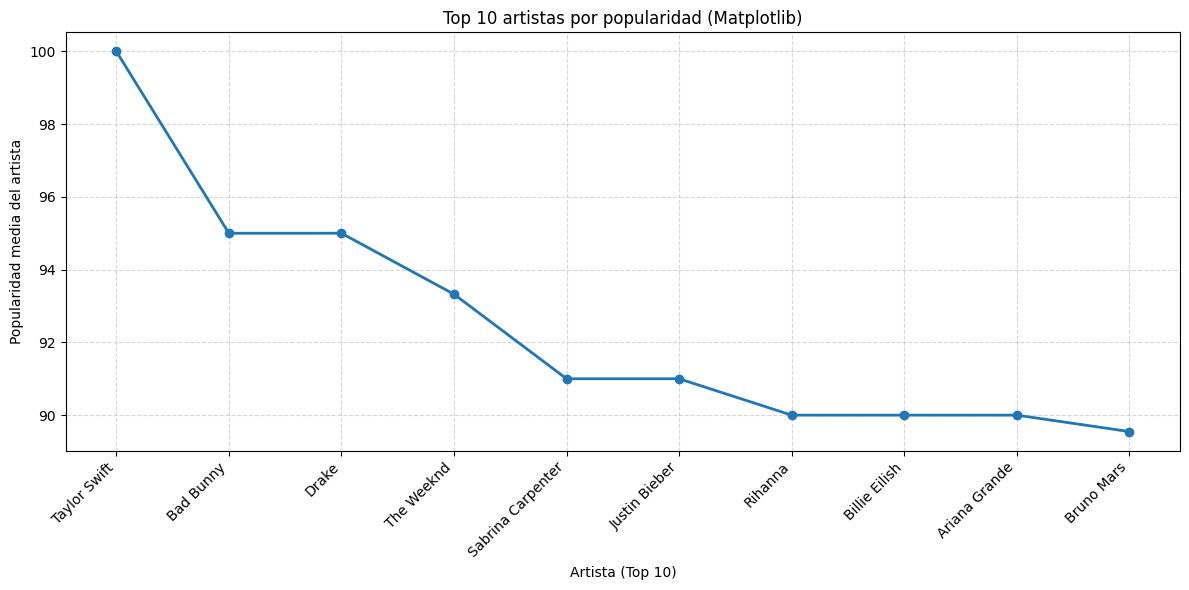

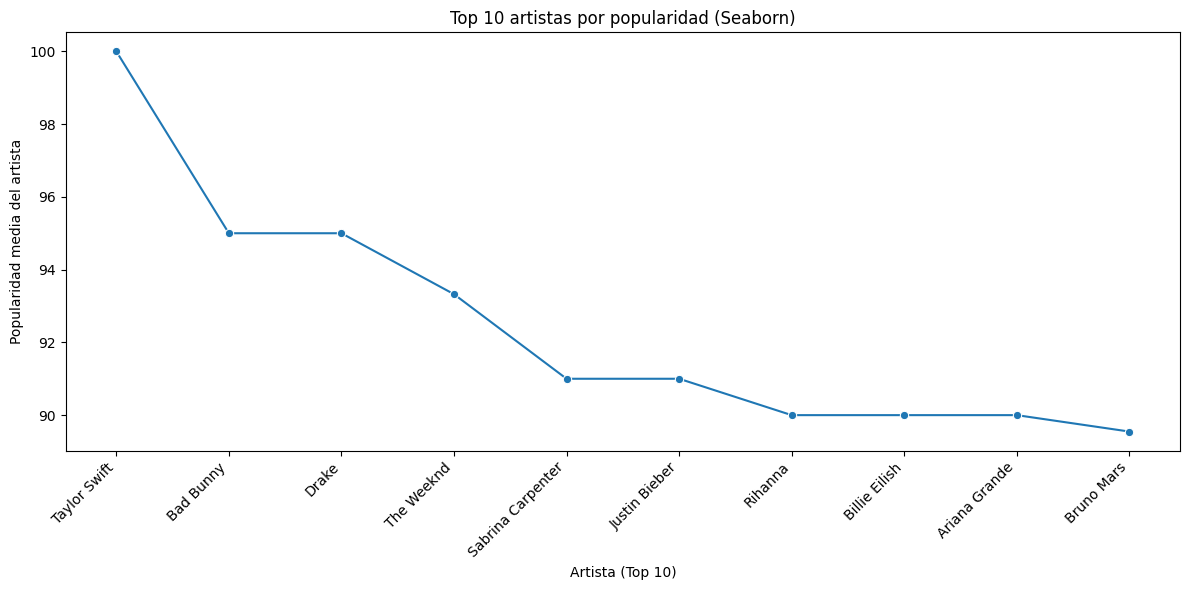

In [16]:
# Obtenemos el top 10 de artistas más populares
top10 = (df.groupby('artist_name', as_index=False)['artist_popularity']
          .mean()
          .sort_values('artist_popularity', ascending=False)
          .head(10))
# Creamos una nueva columna "rank" y sumamos 1 porque si no el top sería del 0 al 9
top10 = top10.reset_index(drop=True)
top10['rank'] = top10.index + 1

# Matplotlib
print()
plt.figure(figsize=(12, 6))
plt.plot(top10['rank'], top10['artist_popularity'],
         marker='o', linestyle='-', color='tab:blue', linewidth=2)
plt.xticks(top10['rank'], top10['artist_name'], rotation=45, ha='right')
plt.xlabel("Artista (Top 10)")
plt.ylabel("Popularidad media del artista")
plt.title("Top 10 artistas por popularidad (Matplotlib)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Seaborn
plt.figure(figsize=(12,6))
sns.lineplot(x='rank', y='artist_popularity', data=top10, marker='o', sort=False)
plt.xticks(top10['rank'], top10['artist_name'], rotation=45, ha='right')
plt.xlabel("Artista (Top 10)")
plt.ylabel("Popularidad media del artista")
plt.title("Top 10 artistas por popularidad (Seaborn)")
plt.tight_layout()
plt.show()

---
### Gráfico de barras

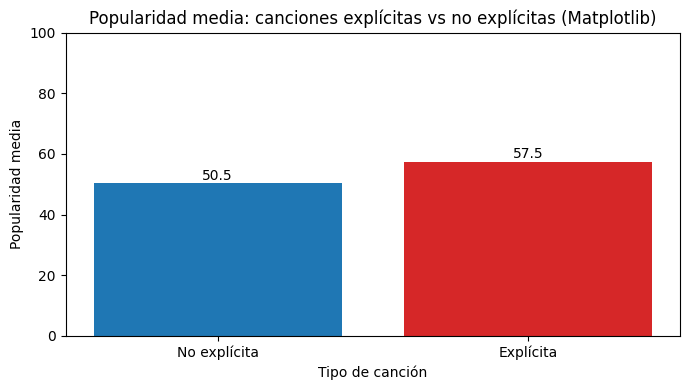

C:\Users\jperaltaza\AppData\Local\Temp\ipykernel_10772\1705268540.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='label', y='avg_popularity', data=group, palette=['tab:blue','tab:red'])


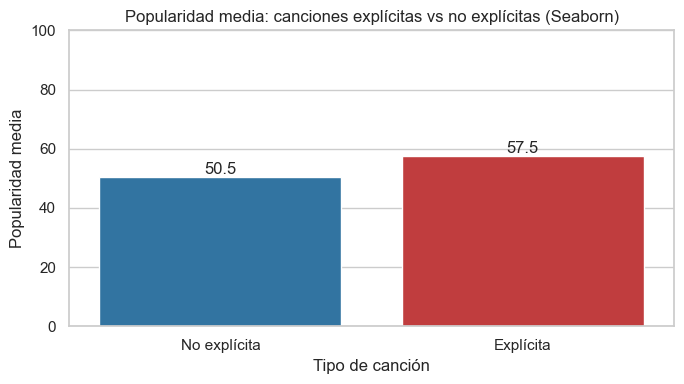

In [18]:
group = (df.groupby('explicit', as_index=False)['track_popularity']
           .mean()
           .rename(columns={'track_popularity':'avg_popularity'}))
group['label'] = group['explicit'].map({False: 'No explícita', True: 'Explícita'})
# Matplotlib
plt.figure(figsize=(7,4))
plt.bar(group['label'], group['avg_popularity'], color=['tab:blue','tab:red'])
plt.ylim(0, 100)
plt.xlabel("Tipo de canción")
plt.ylabel("Popularidad media")
plt.title("Popularidad media: canciones explícitas vs no explícitas (Matplotlib)")
for i, v in enumerate(group['avg_popularity']):
    plt.text(i, v + 1, f"{v:.1f}", ha='center')
plt.tight_layout()
plt.show()

# Seaborn
sns.set_theme(style="whitegrid")
plt.figure(figsize=(7,4))
sns.barplot(x='label', y='avg_popularity', data=group, palette=['tab:blue','tab:red'])
plt.ylim(0, 100)
plt.xlabel("Tipo de canción")
plt.ylabel("Popularidad media")
plt.title("Popularidad media: canciones explícitas vs no explícitas (Seaborn)")
for i, v in enumerate(group['avg_popularity']):
    plt.text(i, v + 1, f"{v:.1f}", ha='center')
plt.tight_layout()
plt.show()

---
### Histograma

---
### Gráfico de dispersión

---
### Gráfico circular